# Trabajo Práctico 1 - Aprendizaje Automático I

**Integrantes: Micaela Gómez, Betsabé Gómez**

En el siguiente trabajo utilizara información de la empresa de remises Uber obtenida del dataset uber_fares.csv con el fin de poder predecir los precios en USD de viajes.   



## **Carga y descarga de librerias necesarias:**





In [102]:
!pip install contextily

In [103]:
#Importamos librerias
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import contextily as cx
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, ElasticNetCV, LassoCV,SGDRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

## **Carga de dataset**

In [104]:
uber = pd.read_csv('/content/uber_fares.csv')

Visualización de las primeras 5 filas del dataset.

In [105]:
uber.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


Este dataset contiene información de tarifas de viajes realizados, además de distintas variables características, como se detallan a continuación.


## **Descripcion de las variables**

**Características de entrada:**



*  **key:** Identificador único de cada viaje.
*  **pickup_datetime:** Fecha y hora de inicio del viaje.

*  **pickup_longitude:** Longitud donde se activó el taxímetro, es decir del inicio del viaje.
* **pickup_latitude:** Latitud donde se activó el taxímetro, es decir es la latitud desde donde se inicio el viaje.

*  **dropoff_longitude:** Es longitud donde se desactivó el taxímetro, es decir de donde finalizo el viaje (lugar de destino).

*  **dropoff_latitude:** Es la latitud del destino del viaje.
* **passenger_count:** Es el número de pasajeros en el vehículo (valor ingresado por el conductor).






**Variable de salida (target):**
*   **fare_amount:** Es el costo de cada viaje en USD

# **Visualización de datos**

Visualizamos la información general de las columnas con sus tipos de datos y valores faltantes.

In [106]:
uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Se observa que el dataset contiene 200.000 filas de las cuales solo tienen un valor faltante las columnas de latitud (dropoff_latitude) y longitud (dropoff_longitude) del destino del viaje.

In [107]:
uber[uber['dropoff_longitude'].isnull()]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [108]:
#Le asigno a una variable la cantidad de filas del dataset original
cant_filas_orig = len(uber)

#Inicializo una variable en 0 para poder calcular que porcentaje estaria borrando del original
cant_filasBorradas = 0

In [109]:
cant_filas = len(uber[uber['dropoff_longitude'].isnull()])

In [110]:
porcent = (cant_filas/cant_filas_orig) *100
porcent

0.0005

Vemos que es una sola fila la que contiene a los dos datos faltantes por lo que procedemos a su eliminación, ya que representa una cantidad insignificante, representa un 0.0005% de los datos muy inferior al 5%.

In [111]:
uber = uber.dropna(subset=['dropoff_longitude']).reset_index(drop=True)

In [112]:
#Como se elimino guardo esa cantidad de filas borradas en la variable cant_filasBorradas
cant_filasBorradas = cant_filas

Se elimina la columna "Date" porque tiene los mismos datos que la columna "pickup_datetime" y se convierte esta columna a tipo de dato datetime.

In [113]:
uber.drop(columns=['date'], inplace=True)

In [114]:
uber['pickup_datetime'] = pd.to_datetime(uber['pickup_datetime'])

## **Resumen estadístico descriptivo:**

Resumen estadistico de las variables numéricas de interés. Se decide sacar la columna key que no tiene sentido hacer una media o análisis numérico de un identificador.

In [115]:
uber[['fare_amount', 'pickup_longitude',
       'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude',
       'passenger_count']].describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Se observa que el 50% de los datos de nuestra variable a predecir fare_amount que son los precios en USD de los viajes rondan los 8.43 USD, presentando un valor máximo de 503 USD (posible outliers). Además, en la columna passenger_count (cantidad de pasajeros) aparece un máximo de 208 por lo que se puede apreciar que es un valor irreal (valor atipico). En las columnas referidas a la longitud se observan valores atipicos también ya que los valores válidos van en un rango de -180 a 180 y la latitud sus valores válidos son de -90 a 90.


Se verifica los valores únicos de la columna passenger_count (cantidad de pasajeros)

In [116]:
uber['passenger_count'].unique()

array([  1,   3,   5,   2,   4,   6,   0, 208])

Se observa datos inválidos como cantidad de pasajero 0 y 208

In [117]:
uber[(uber['passenger_count'] == 208) | (uber['passenger_count'] == 0)]


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
333,2137942,10.1,2011-08-05 07:03:08+00:00,-74.013900,40.707800,-73.992300,40.749300,0
908,8484351,11.7,2011-09-06 12:25:19+00:00,-73.981000,40.764600,-73.962900,40.778400,0
926,32941306,3.3,2012-03-26 18:11:24+00:00,-73.979978,40.765821,-73.983894,40.766873,0
2000,12591041,15.7,2012-04-20 15:07:57+00:00,-73.975285,40.750138,-73.974729,40.783151,0
3011,39400625,6.1,2012-01-07 19:19:08+00:00,-73.977900,40.789100,-73.983700,40.773600,0
...,...,...,...,...,...,...,...,...
196796,26965490,3.3,2011-01-17 15:52:26+00:00,-74.000760,40.757637,-74.004852,40.751947,0
197102,49116579,7.3,2011-12-10 15:33:12+00:00,0.000000,0.000000,0.000000,0.000000,0
198871,12988511,5.7,2011-09-20 19:55:05+00:00,-73.980300,40.742800,-73.967900,40.755600,0
198901,54393172,12.1,2011-08-22 21:10:56+00:00,-73.996700,40.737200,-74.008500,40.704000,0


Se observan que son 709 filas las que tienen datos inválidos en cantidad de pasajeros.

In [118]:
cant_filas = len(uber[(uber['passenger_count'] == 208) | (uber['passenger_count'] == 0)])

In [119]:
#Calculo el porcentaje de datos a borrar con los que se eliminaron
cant_filasBorradas = cant_filasBorradas + cant_filas

(cant_filasBorradas/cant_filas_orig)*100

0.35500000000000004

Se procede a la eliminaciòn ya que es menor al 5%

In [120]:
uber = uber[uber['passenger_count'] != 208].reset_index(drop=True)

In [121]:
uber = uber[uber['passenger_count'] != 0].reset_index(drop=True)

Se busca las filas donde las coordenadas son inválidas tanto de origen como de destino del viaje, es decir que los valores no esten en los siguientes rangos.


*  **Latitud:** -90 a 90
*  **Longitud:** -180 a 180




Junto con los datos fuera de estos rangos se eliminan aquellos viajes donde el origen o destino son tanto de longitud como de latitud 0. Ya que este punto es invalido por estar en medio del océano.

In [122]:
errores_coord = uber[ (uber['pickup_latitude'] < -90) | (uber['pickup_latitude'] > 90)|
    (uber['dropoff_latitude'] < -90) | (uber['dropoff_latitude'] > 90)
| (uber['pickup_longitude'] < -180) | (uber['pickup_longitude'] > 180) |
  (uber['dropoff_longitude'] < -180) |  (uber['dropoff_longitude'] > 180)|
  ((uber['pickup_longitude'] == 0) & (uber['pickup_latitude'] == 0)) |
     ((uber['dropoff_longitude'] == 0) & (uber['dropoff_latitude'] == 0))]

errores_coord

,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
7,44195482,2.5,2012-12-11 13:52:00+00:00,0.0,0.000000,0.000000,0.000000,1
11,6379048,8.5,2011-05-23 22:15:00+00:00,0.0,0.000000,0.000000,0.000000,1
65,21993993,6.0,2014-05-05 19:27:00+00:00,0.0,0.000000,0.000000,0.000000,1
92,1454546,6.1,2011-12-02 14:07:00+00:00,0.0,0.000000,0.000000,0.000000,1
120,17358122,6.5,2010-08-20 19:39:48+00:00,0.0,0.000000,0.000000,0.000000,1
...,...,...,...,...,...,...,...,...
199014,46007628,7.5,2013-10-11 11:25:41+00:00,0.0,0.000000,0.000000,0.000000,1
199170,35013970,6.5,2014-02-22 06:45:46+00:00,0.0,0.000000,0.000000,0.000000,1
199173,44115598,12.5,2012-09-10 17:39:00+00:00,0.0,0.000000,0.000000,0.000000,2
199226,44787414,4.1,2012-07-21 16:19:00+00:00,-736.4,40.774307,-73.982215,40.769672,5


In [123]:
print(f" Cantidad de filas con errores en coordenadas: {len(errores_coord)}")

 Cantidad de filas con errores en coordenadas: 3938


In [124]:
#Suma de contador
cant_filasBorradas = cant_filasBorradas + len(errores_coord)

cant_filasBorradas

4648

In [125]:
(cant_filasBorradas/cant_filas_orig)*100

2.324

El porcentaje sigue siendo menor al 5% por lo que se procede a su eliminación.

In [126]:
uber = uber.drop(errores_coord.index)

Se ubican las coordenadas del origen y destino de los viajes en un mapa, usando Geopandas.

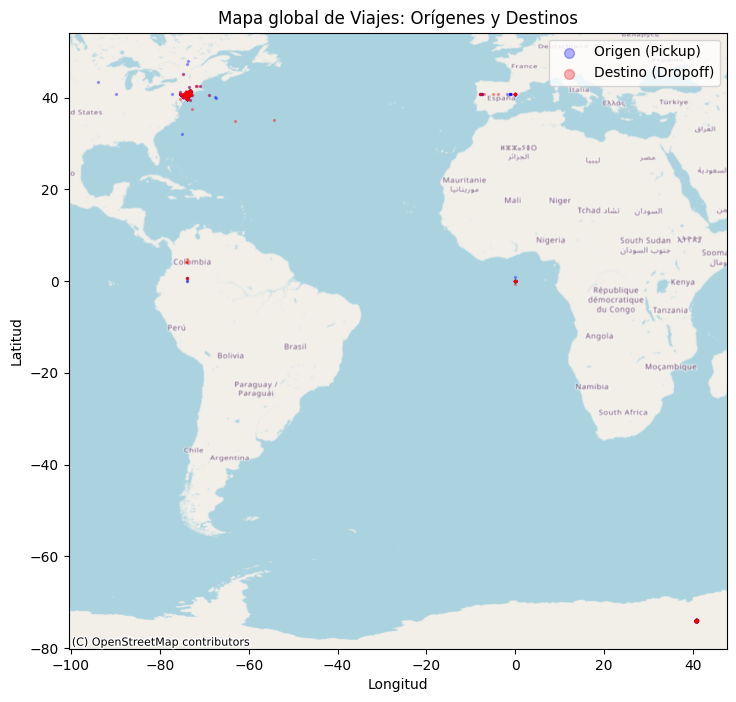

In [127]:
#Geodataframe del inicio del viaje
geo_uber_pickup = gpd.GeoDataFrame(
    uber,
    geometry=gpd.points_from_xy(uber.pickup_longitude, uber.pickup_latitude),
    crs="EPSG:4326"
)

#Geodataframe del destino del viaje
geo_uber_dropoff = gpd.GeoDataFrame(
    uber,
    geometry=gpd.points_from_xy(uber.dropoff_longitude, uber.dropoff_latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 8))

geo_uber_pickup.plot(
    ax=ax,
    color='blue',
    markersize=2,
    alpha=0.3,
    label='Origen (Pickup)'
)

geo_uber_dropoff.plot(
    ax=ax,
    color='red',
    markersize=2,
    alpha=0.3,
    label='Destino (Dropoff)'
)

cx.add_basemap(ax, crs=geo_uber_pickup.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

plt.legend(markerscale=5)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa global de Viajes: Orígenes y Destinos")

plt.show()

El mapa muestra viajes en distintas zonas geográficas, por practicidad el análisis se limitará a Nueva York. considerando únicamente las coordenadas dentro del siguiente rango:

Latitud: 40.55 a 40.90
Longitud: -74.10 a -73.75

In [128]:
uber_filtrado = uber[((uber['pickup_longitude'] >= -74.10) & (uber['pickup_longitude'] <= -73.75))
& ((uber['pickup_latitude'] >= 40.55)&(uber['pickup_latitude']<= 40.90))
& ((uber['dropoff_longitude'] >= -74.10) & (uber['dropoff_longitude'] <= -73.75))
& ((uber['dropoff_latitude'] >= 40.55)&(uber['dropoff_latitude']<= 40.90) &
   ((uber['pickup_latitude'] != uber['dropoff_latitude'])
   & (uber['pickup_longitude'] != uber['dropoff_longitude'])))].copy()

In [129]:
print(f"La zona geográfica elegida representa el {(len(uber_filtrado)/cant_filas_orig)*100}% de los datos originales.")

La zona geográfica elegida representa el 96.151% de los datos originales.


In [130]:
print(f"El dataset original tenia {cant_filas_orig}. El nuevo dataframe tiene {len(uber_filtrado)} y las filas borradas fueron {cant_filas_orig - len(uber_filtrado)}")

El dataset original tenia 200000. El nuevo dataframe tiene 192302 y las filas borradas fueron 7698


Se visualiza el inicio/destino de los viajes hechos en EEUU.

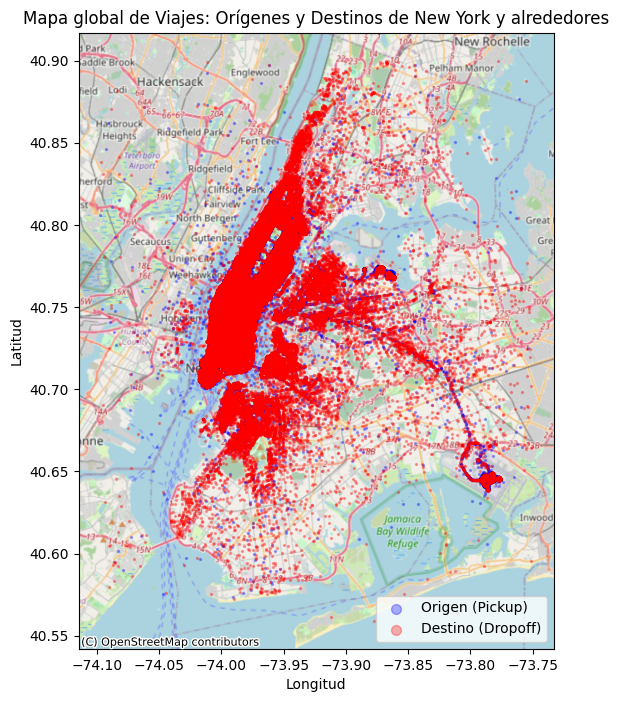

In [131]:
#Geodataframe del inicio del viaje
geo_uber_pickup2 = gpd.GeoDataFrame(
    uber_filtrado,
    geometry=gpd.points_from_xy(uber_filtrado.pickup_longitude, uber_filtrado.pickup_latitude),
    crs="EPSG:4326"
)

#Geodataframe del destino del viaje
geo_uber_dropoff2 = gpd.GeoDataFrame(
    uber_filtrado,
    geometry=gpd.points_from_xy(uber_filtrado.dropoff_longitude, uber_filtrado.dropoff_latitude),
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(12, 8))

geo_uber_pickup2.plot(
    ax=ax,
    color='blue',
    markersize=2,
    alpha=0.3,
    label='Origen (Pickup)'
)

geo_uber_dropoff2.plot(
    ax=ax,
    color='red',
    markersize=2,
    alpha=0.3,
    label='Destino (Dropoff)'
)


cx.add_basemap(ax, crs=geo_uber_pickup2.crs.to_string(), source=cx.providers.OpenStreetMap.Mapnik)

plt.legend(markerscale=5)
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa global de Viajes: Orígenes y Destinos de New York y alrededores")

plt.show()

Se visualiza la distribución de la variable precio del viaje en USD

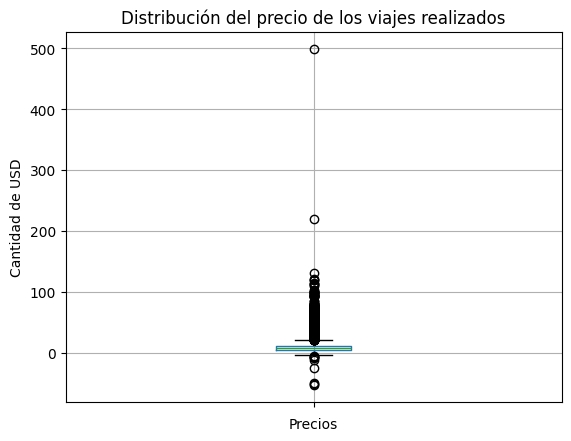

In [132]:
uber_filtrado.boxplot(column='fare_amount')
plt.xlabel("Precios")
plt.ylabel("Cantidad de USD")
plt.title("Distribución del precio de los viajes realizados")
plt.xticks([1], [''])
plt.show()

Se observa que el 50% de los viajes estan alrededor de los 8,41 USD y que presenta muchos valores atípicos con valores muy altos. La distribución se encuentra muy sesgada a la derecha.

Se visualiza la distribución de la cantidad de pasajeros

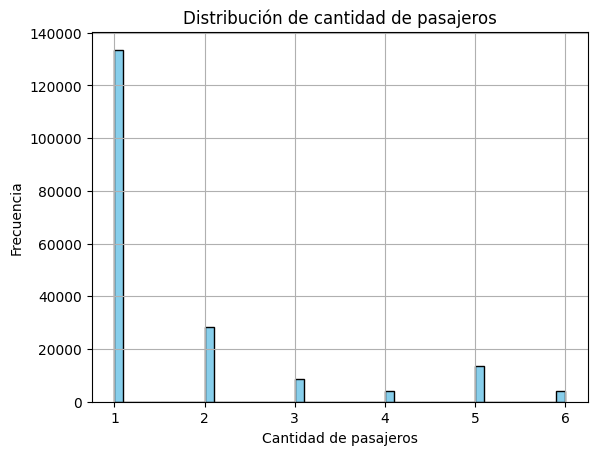

In [133]:
# Histograma de cantidad de pasajeros
uber_filtrado['passenger_count'].hist(bins=50, color='skyblue', edgecolor='black')

plt.title('Distribución de cantidad de pasajeros')
plt.xlabel('Cantidad de pasajeros')
plt.ylabel('Frecuencia')
plt.show()

Se observa en el gráfico que la cantidad de pasajeros osila entre 1 y 6 pasajeros y que en la mayoria de los viajes realizados se subió al uber una sola persona. El resto de las cantidades de pasajeros son menos frecuentes.  

**Visualización de rango de fechas de los viajes realizados.**

In [134]:
uber_filtrado['pickup_datetime'].min()

Timestamp('2009-01-01 01:15:22+0000', tz='UTC')

In [135]:
uber_filtrado['pickup_datetime'].max()

Timestamp('2015-06-30 23:40:39+0000', tz='UTC')

El primer registro de viaje fue el 01/01/2009 y el último el 30/06/2015

In [136]:
uber_filtrado['anio'] = uber_filtrado['pickup_datetime'].dt.year

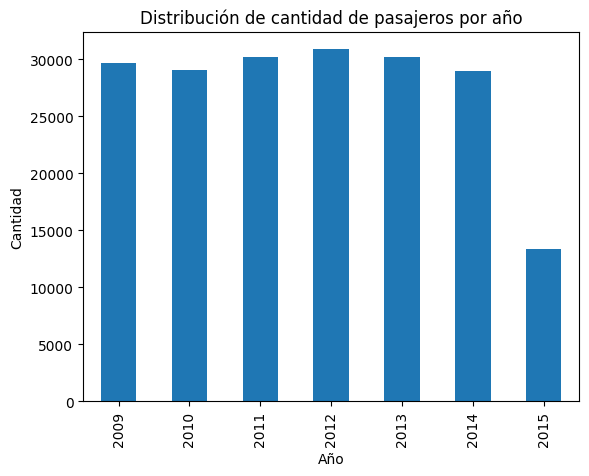

In [137]:
uber_filtrado['pickup_datetime'].dt.year.value_counts().sort_index().plot(kind='bar')
plt.xlabel('Año')
plt.ylabel('Cantidad')
plt.title('Distribución de cantidad de pasajeros por año')
plt.show()

Desde el 2009 hasta el 2014 se puede observar que en el año 2012 hubo una mayor cantidad de viajes realizados, sin embargo las cantidades no presentan mucha diferencia. Mientras que en el 2015 se ve una disminución en la cantidad de viajes, esto se debe porque tenemos información hasta el 30/06/2015.

**Distribución de la cantidad de viajes por meses.**

In [138]:
meses = {
    1: 'Enero',
    2: 'Febrero',
    3: 'Marzo',
    4: 'Abril',
    5: 'Mayo',
    6: 'Junio',
    7: 'Julio',
    8: 'Agosto',
    9: 'Septiembre',
    10: 'Octubre',
    11: 'Noviembre',
    12: 'Diciembre'
}

In [139]:
uber_filtrado['mes'] = uber_filtrado['pickup_datetime'].dt.month

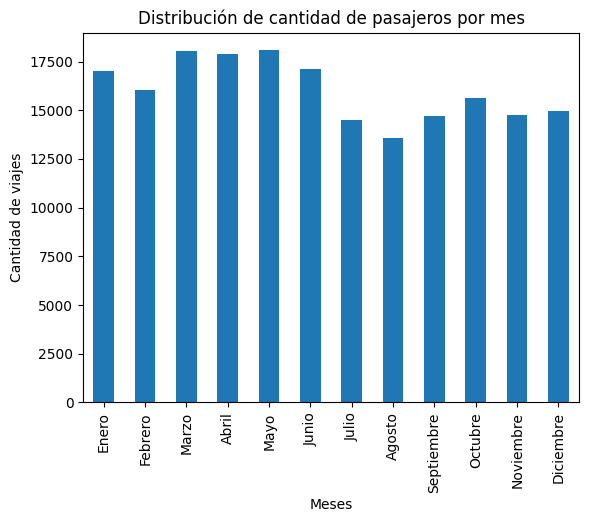

In [140]:
cantidad_por_mes = uber_filtrado['pickup_datetime'].dt.month.value_counts().sort_index()
cantidad_por_mes.index = cantidad_por_mes.index.map(meses)

cantidad_por_mes.plot(kind='bar')
plt.title('Distribución de cantidad de pasajeros por mes')
plt.xlabel('Meses')
plt.ylabel('Cantidad de viajes')
plt.show()

La mayor cantidad de viajes ocurre de marzo a mayo y en junio empieza a decaer. En septiembre vuelven a remontar un poco pero no a la altura de los meses más altos.

**Distribución de la cantidad de viajes por día.**

In [141]:
#Codificación de días de la semana
uber_filtrado["dia"] = uber_filtrado["pickup_datetime"].dt.weekday

In [142]:
dias = {
    0: 'Lunes',
    1: 'Martes',
    2: 'Miércoles',
    3: 'Jueves',
    4: 'Viernes',
    5: 'Sábado',
    6: 'Domingo'
}

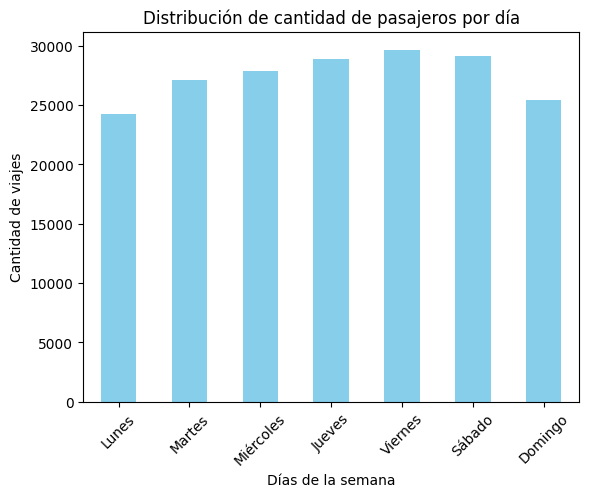

In [143]:
cantidad_por_dia = uber_filtrado['pickup_datetime'].dt.day_of_week.value_counts().sort_index()
cantidad_por_dia.index = cantidad_por_dia.index.map(dias)
cantidad_por_dia.plot(kind='bar', color='skyblue')

plt.title('Distribución de cantidad de pasajeros por día')
plt.xlabel('Días de la semana')
plt.ylabel('Cantidad de viajes')
plt.xticks(rotation=45)

plt.show()

Los días con mayor frecuencia de viajes se da los días viernes, seguido del sábado y el jueves.

**Distribución de la cantidad de viajes por hora.**

In [144]:
#Agrega una columna hora con solo la hora
uber_filtrado["hora"] = uber_filtrado["pickup_datetime"].dt.hour

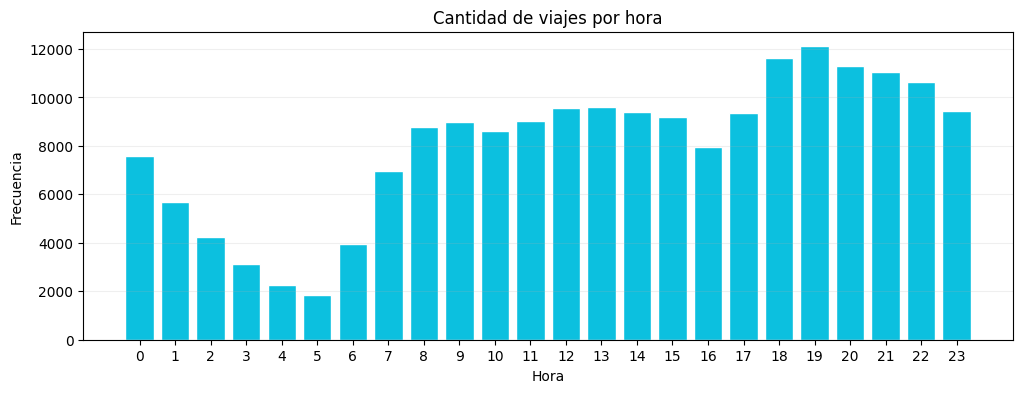

In [145]:
conteo = uber_filtrado["hora"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo.index, conteo.values, color="#0cc0df", edgecolor="#FFFFFF")
plt.xticks(conteo.index)
plt.title("Cantidad de viajes por hora")
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

La mayor cantidad de viajes se da entre las 18 y 22 horas.

**Visualización de frecuencia del dia domingo por hora**

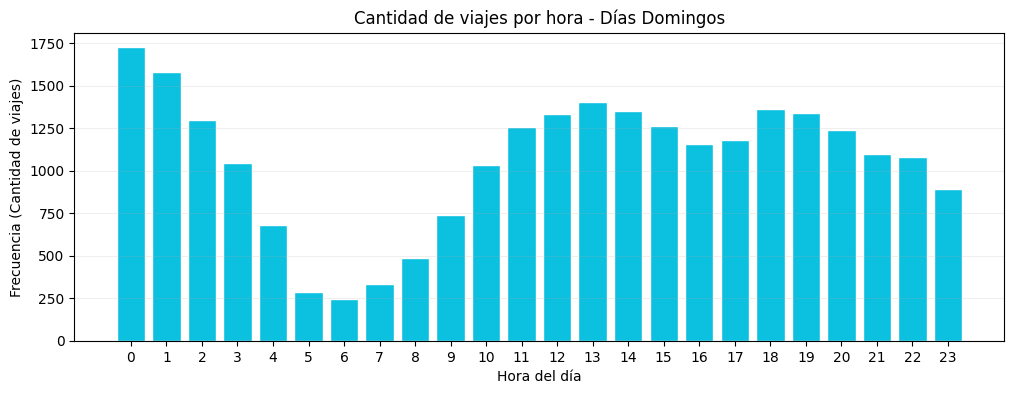

In [146]:
viajes_domingo = uber_filtrado[uber_filtrado["dia"] == 6]

conteo_horas = viajes_domingo["hora"].value_counts().sort_index()

plt.figure(figsize=(12, 4))
plt.bar(conteo_horas.index, conteo_horas.values, color="#0cc0df", edgecolor="#FFFFFF")

plt.xticks(range(24))

plt.title("Cantidad de viajes por hora - Días Domingos")
plt.xlabel("Hora del día")
plt.ylabel("Frecuencia (Cantidad de viajes)")
plt.grid(True, axis="y", alpha=0.2)
plt.show()

Se observa que a diferencia del gráfico general anterior la mayor concurrencia de viajes ocurre de las 0 a las 1 de la mañana.

**Distancia de Manhattan**

In [147]:
def manhattan_dist(lat1, lon1, lat2, lon2):
    """
    Calcula la Distancia de Manhattan entre dos
    puntos geográficos en kilómetros.

    Parámetros:
    lat1, lon1: Latitud y Longitud del punto de partida.
    lat2, lon2: Latitud y Longitud del punto de destino.

    Devuelve:
    La distancia aproximada de Manhattan en kilómetros.
    """
    R = 6371

    delta_lat = np.abs(lat2 - lat1)
    delta_lon = np.abs(lon2 - lon1)

    lat_to_km = 111.32
    lon_to_km = 111.32

    distance_km = (delta_lat * lat_to_km) + (delta_lon * lon_to_km)

    return round(distance_km,4)

In [148]:
#Se agrega una columna con los kilometros recorrido
uber_filtrado['distancia_km'] = manhattan_dist(
    uber_filtrado['pickup_latitude'],
    uber_filtrado['pickup_longitude'],
    uber_filtrado['dropoff_latitude'],
    uber_filtrado['dropoff_longitude']
)

In [149]:
#uber_filtrado.head(5)

**Distribucion de la distancia en kilómetros**

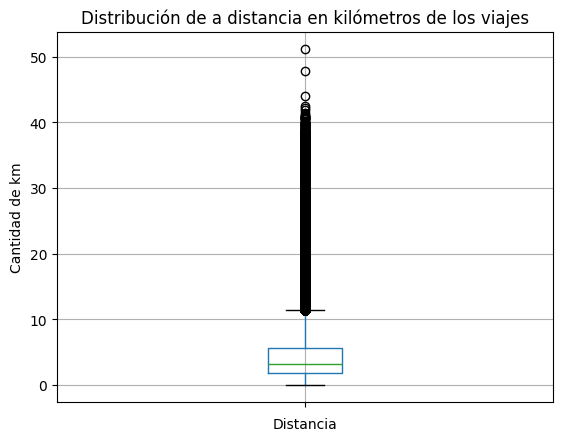

In [150]:
uber_filtrado.boxplot(column='distancia_km')
plt.xlabel("Distancia")
plt.ylabel("Cantidad de km")
plt.title("Distribución de a distancia en kilómetros de los viajes")
plt.xticks([1], ['']) #Oculta nombre de columna
plt.show()

In [151]:
uber_filtrado['distancia_km'].describe()

,distancia_km
count,192302.000000
mean,4.882729
std,5.439853
min,0.000200
25%,1.860400
50%,3.160450
75%,5.666100
max,51.211900


Se visualiza que la concentación esta entre 1,86 km y 5,66 km. Se observan varios valores atípicos que los viajes superaron los 10 km de distancia recorridos, teniendo un máximo de 51,21 km.  





**Distribución del precio por dia y hora**

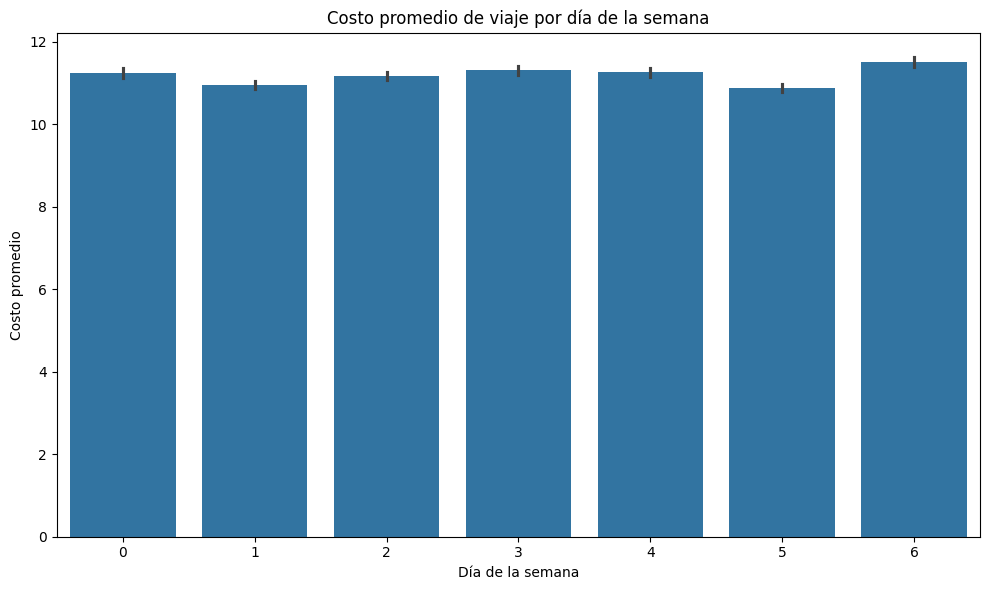

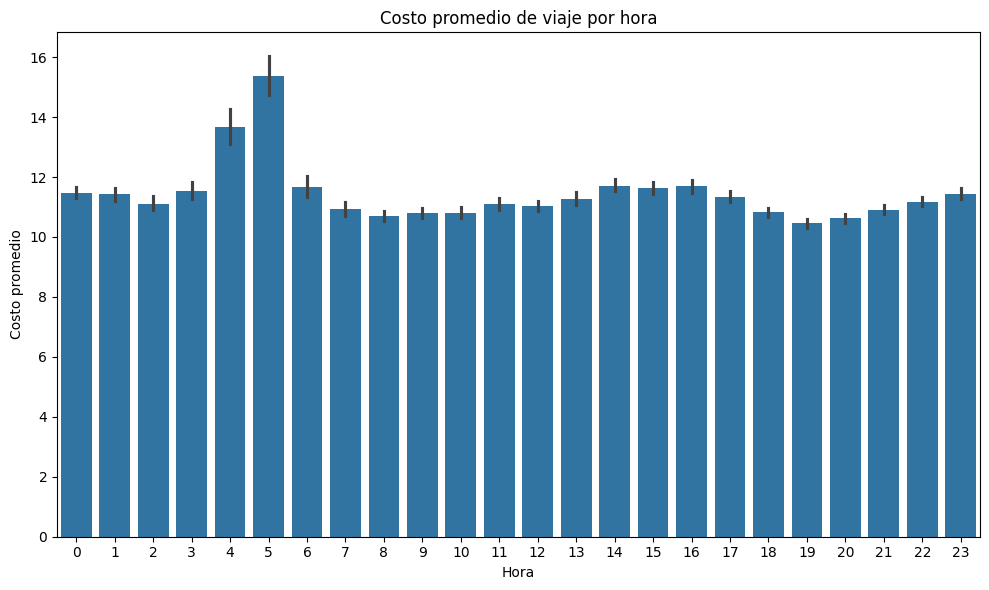

In [152]:
plt.figure(figsize=(10, 6))
sns.barplot(x='dia', y='fare_amount', estimator='mean', data=uber_filtrado)
plt.title('Costo promedio de viaje por día de la semana')
plt.xlabel('Día de la semana')
plt.ylabel('Costo promedio')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='hora', y='fare_amount', data=uber_filtrado)
plt.title('Costo promedio de viaje por hora')
plt.xlabel('Hora')
plt.ylabel('Costo promedio')
plt.tight_layout()
plt.show()

Los precios en relación a los días de la semana no presentan diferencias significativas, sin embargo al comparar las horas con el promedio de precio, se concluye que hay un aumento del precio promedio a las 5 am (quizás se deba a que puede haber pocos choferes trabajando, ya que en un anterior se observo que no hubo tantos viajes en ese horario)  

# **Matriz de correlación**

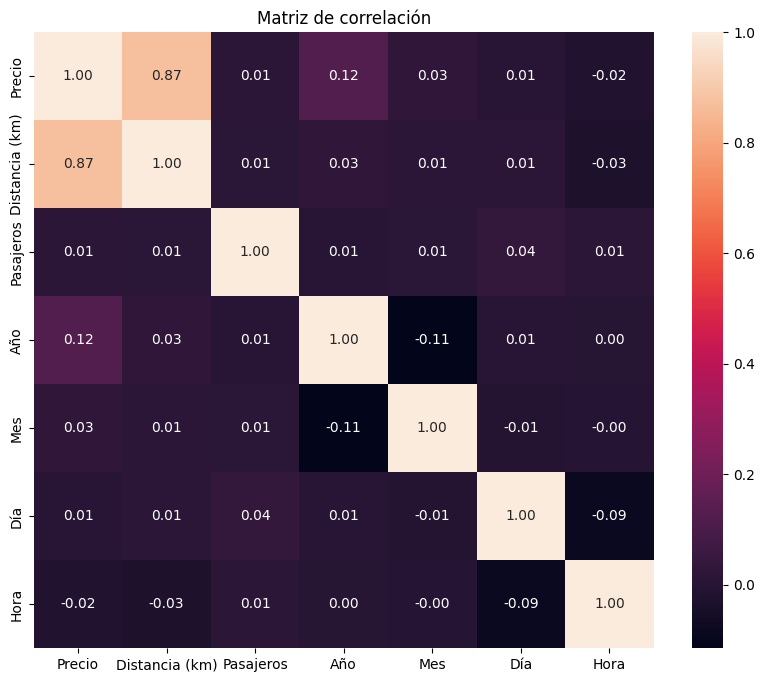

In [153]:
columns = [
    "fare_amount",
    "distancia_km",
    "passenger_count",
    "anio",
    "mes",
    "dia",
    "hora"]

corr = uber_filtrado[columns].corr(numeric_only=True)

nombres = {
    "fare_amount": "Precio",
    "distancia_km": "Distancia (km)",
    "passenger_count": "Pasajeros",
    "anio": "Año",
    "mes": "Mes",
    "dia": "Día",
    "hora": "Hora"}

corr = corr.rename(index=nombres, columns=nombres)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Matriz de correlación")
plt.show()


La presente matriz de correlación muestra que hay una fuerte relación lineal positiva entre el precio del viaje y los kilómetros recorridos, es decir a mayor distancia, mayor es el precio. Mientras que las demás variables tienen una relación muy baja.

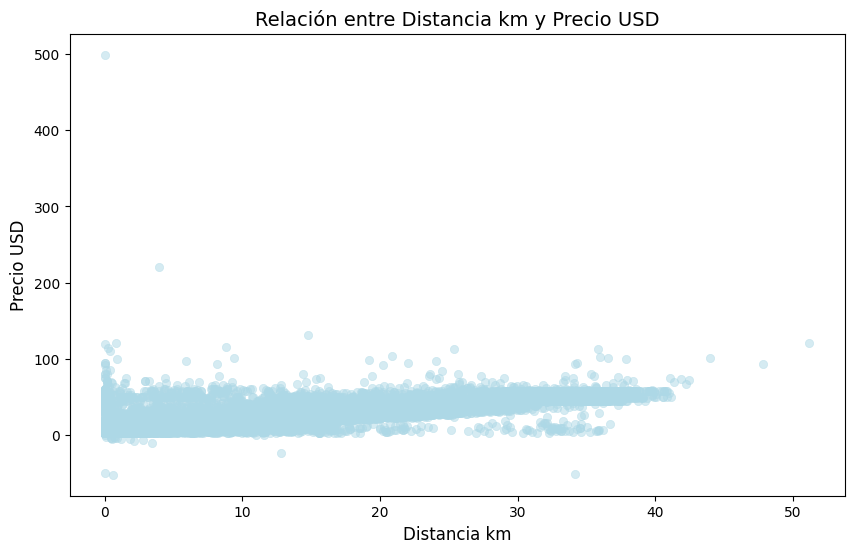

In [154]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=uber_filtrado['distancia_km'], y=uber_filtrado['fare_amount'],
                color='lightblue', alpha=0.5, edgecolor=None)

plt.title('Relación entre Distancia km y Precio USD', fontsize=14)
plt.xlabel('Distancia km', fontsize=12)
plt.ylabel('Precio USD', fontsize=12)

plt.show()

Se observa una relación lineal dependiente positiva, a mayor distancia, mayor cantidad de dólares.

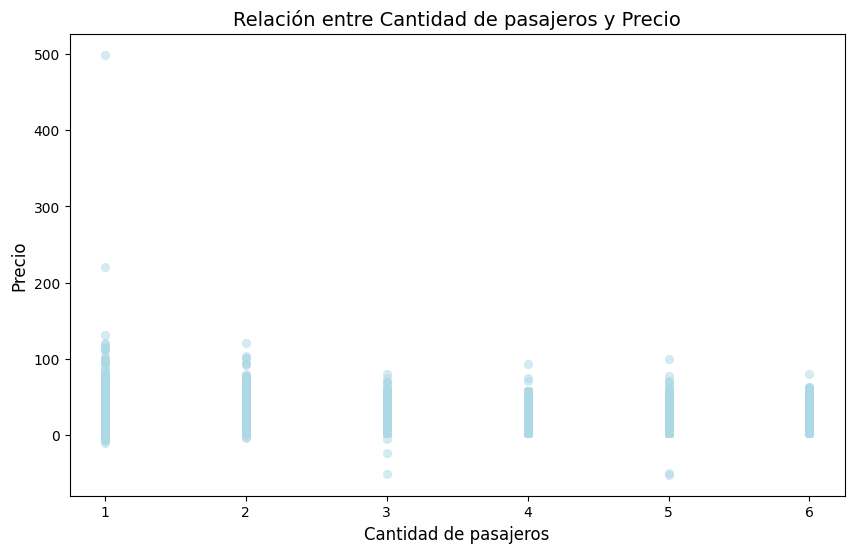

In [155]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=uber_filtrado['passenger_count'], y=uber_filtrado['fare_amount'],
                color='lightblue', alpha=0.5, edgecolor=None)

plt.title('Relación entre Cantidad de pasajeros y Precio', fontsize=14)
plt.xlabel('Cantidad de pasajeros', fontsize=12)
plt.ylabel('Precio', fontsize=12)

plt.show()

Al ver este gráfico se decide excluir de las features la variable "passenger_count", porque no afecta a la predicción del precio en dólares. Además, viendo la matriz de correlación es muy baja e insignificante respecto a la variable a predecir.

# **Modelado**

In [156]:
features = [
    'distancia_km',
    'hora', 'mes', 'anio','dia'
]

X = uber_filtrado[features]
y = uber_filtrado['fare_amount']

X_entr, X_test, y_entr, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_entr, y_entr, test_size=0.25, random_state=42
)

print(f"Registros totales: {len(X)}")
print(f"Entrenamiento: {len(X_train)} filas")
print(f"Validación:    {len(X_val)} filas")
print(f"Prueba (Test): {len(X_test)} filas")



Registros totales: 192302
Entrenamiento: 115380 filas
Validación:    38461 filas
Prueba (Test): 38461 filas


In [157]:
x_scaler = StandardScaler()

X_train_sc = x_scaler.fit_transform(X_train)
X_val_sc   = x_scaler.transform(X_val)
X_test_sc  = x_scaler.transform(X_test)

## **Regresión Lineal**

In [158]:
model = LinearRegression()

In [159]:
model.fit(X_train_sc, y_train)

LinearRegression()

In [160]:
predicciones = model.predict(X=X_test_sc)
predicciones = predicciones.flatten()
predicciones[:10]

array([ 7.19872582, 36.02247665,  9.46403189,  6.3861463 ,  9.62583372,
        8.30216454,  9.00409517,  6.12198056, 13.36631517,  4.38916347])

# **Métodos de gradiente descendiente**

In [161]:
def batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente por Lotes (BGD) para Regresión Lineal.
    Usa X_test/y_test para monitorear el error de generalización.

    Las variables de entrada se convierten a NumPy y se ajusta la forma (n, 1) internamente.
    """
    X_train = np.array(X_train)
    X_test = np.array(X_test)

    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]
    p = X_test.shape[0]

    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((p, 1)), X_test))

    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []
    test_errors = []

    for _ in range(epochs):
        prediction_train = np.matmul(X_train_b, W)

        error_train = y_train - prediction_train
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        prediction_test = np.matmul(X_test_b, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        grad_sum = np.sum(error_train * X_train_b, axis=0)
        grad_mul = -2/n * grad_sum
        gradient = grad_mul.reshape(-1, 1)

        W = W - (lr * gradient)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio(Loss)')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Iteraciones (BGD, lr={lr})')
    plt.grid(True)
    plt.show()

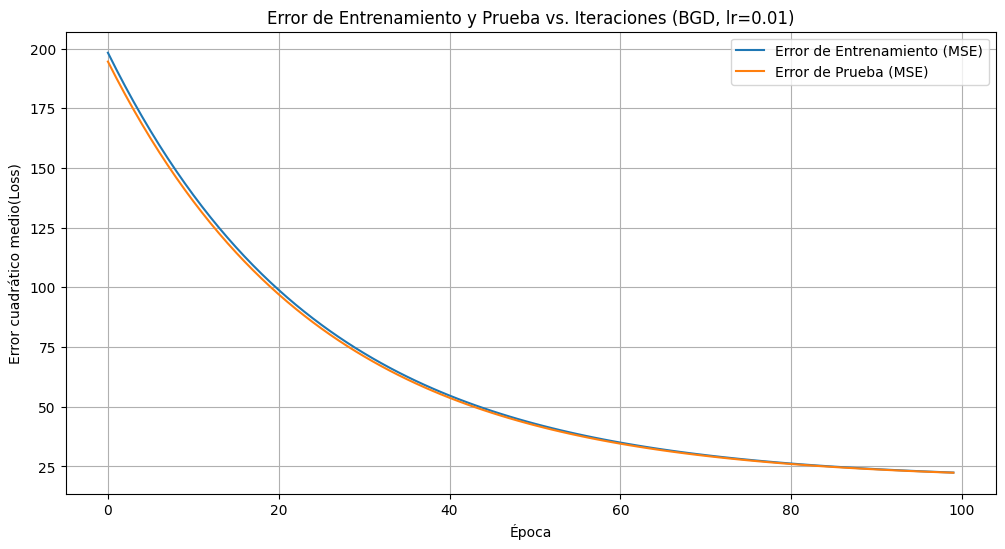

In [162]:
batch_gradient_descent(X_train_sc, y_train, X_val_sc, y_val)


Descenso de Gradiente por Lotes (BGD): Presentó las curvas de entrenamiento y validación superpuestas durante todo el entrenamiento, lo que confirma una buena generalización. Sin embargo, resultó ser el método más lento: con 100 épocas y lr=0.01 no logró converger completamente, finalizando con un MSE de aproximadamente 23.

In [163]:

def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente Estocástico (SGD) para Regresión Lineal.
    Usa un solo ejemplo aleatorio para cada actualización.
    """

    X_train = np.array(X_train)
    X_test = np.array(X_test)

    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = []
    test_errors_plot = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        epoch_train_mse = []

        for j in range(n):
            x_sample = X_train[j].reshape(1, -1)
            y_sample = y_train[j].reshape(1, -1)

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction

            mse_sample = error ** 2
            epoch_train_mse.append(mse_sample[0, 0])

            gradient = -2 * error * x_sample.T

            W = W - (lr * gradient)

        train_errors_plot.append(np.mean(epoch_train_mse))

        prediction_test = np.matmul(X_test, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio(Loss)')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (SGD, lr={lr})')
    plt.grid(True)
    plt.show()

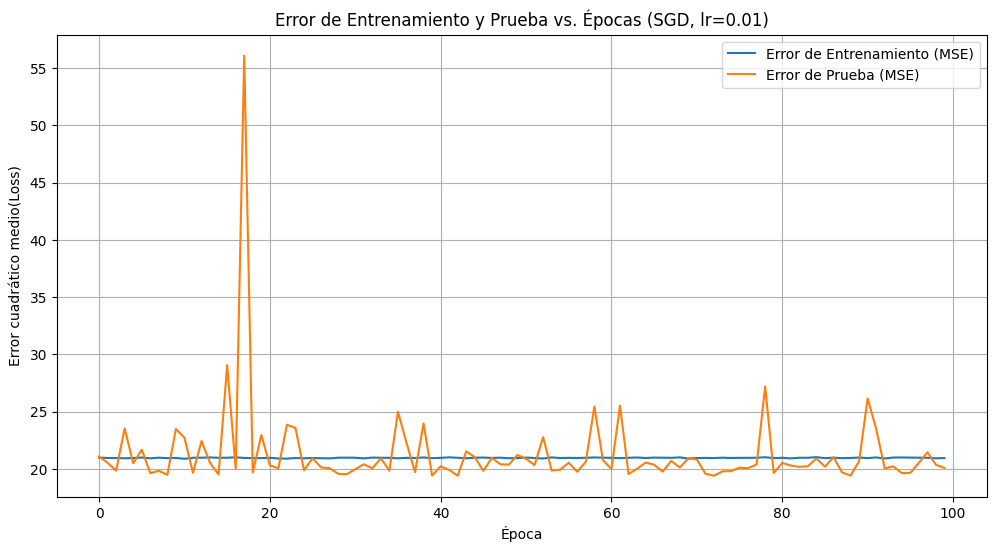

In [164]:
stochastic_gradient_descent(X_train_sc, y_train, X_val_sc, y_val)

Descenso de Gradiente Estocástico (SGD): Alcanzó un MSE aproximadante de 21 pero muestra una alta inestabilidad en la curva de validación, con picos pronunciados a lo largo de todas las épocas.

In [165]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=64):
    """
    Implementa Mini-Batch GD para Regresión Lineal.
    Actualiza los pesos usando un subconjunto de datos (mini-lote) en cada iteración.
    """
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = []
    test_errors_plot = []

    for i in range(epochs):
        permutation = np.random.permutation(n)
        X_shuffled = X_train_b[permutation]
        y_shuffled = y_train[permutation]

        epoch_train_mse = []

        for j in range(0, n, batch_size):
            x_batch = X_shuffled[j:j+batch_size, :]
            y_batch = y_shuffled[j:j+batch_size]

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction

            mse_batch = np.mean(error ** 2)
            epoch_train_mse.append(mse_batch)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size
            W = W - (lr * gradient)

        train_errors_plot.append(np.mean(epoch_train_mse))

        prediction_test = np.matmul(X_test_b, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio(Loss)')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (Mini-Batch GD, size={batch_size}, lr={lr})')
    plt.grid(True)
    plt.show()

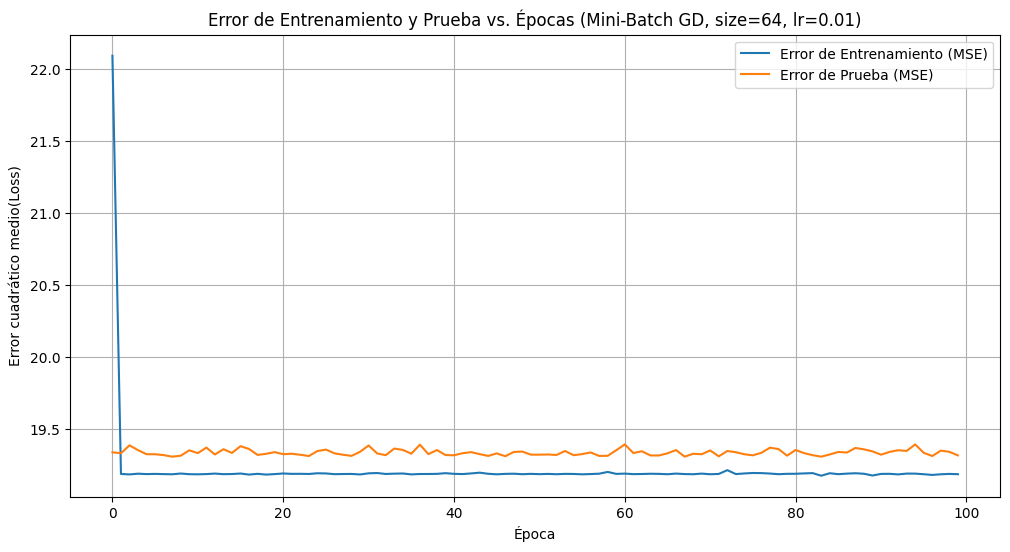

In [166]:
mini_batch_gradient_descent(X_train_sc, y_train, X_val_sc, y_val)

Descenso de Gradiente por Mini-Lotes (Mini-Batch GD): Demostró ser el método más eficiente. Convergió casi instantáneamente durante la primera época, alcanzando el MSE más bajo en aproximandamente 19.3, manteniéndose estable hasta el final. Logra el balance óptimo entre la precisión del BGD y la velocidad del SGD.

# Métodos de regularización: Lasso, Ridge, Elastic Net


Resultados óptimos:
Mejor Ridge Alpha: 1526.4180 (MSE: 19.3073)
Mejor Lasso Alpha: 0.0193 (MSE: 19.3129)
Mejor Elastic Net Alpha: 0.0193 (MSE: 19.3075)


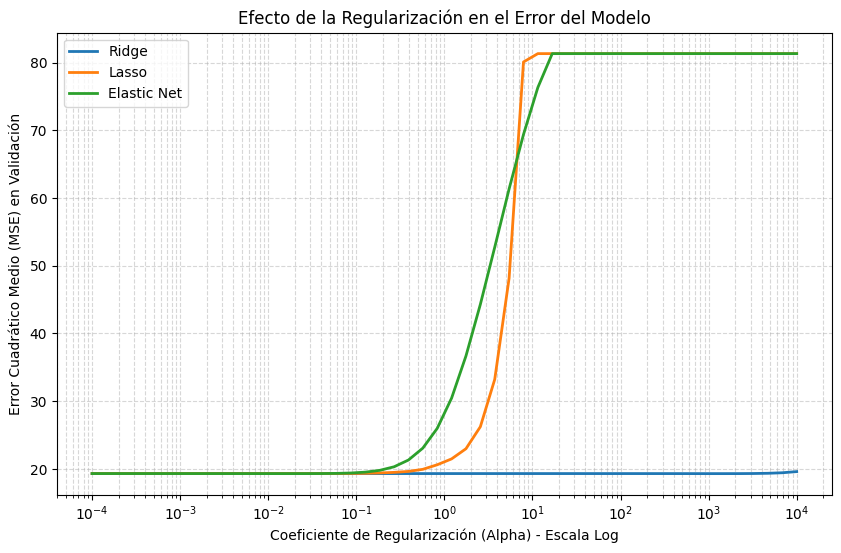

In [167]:
alphas = np.logspace(-4, 4, 50) #rangos amplios de coeficientes de regularización

errores_ridge = []
errores_lasso = []
errores_elastic = []


for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=42)
    ridge.fit(X_train_sc, y_train)
    pred_ridge = ridge.predict(X_val_sc)
    errores_ridge.append(mean_squared_error(y_val, pred_ridge))

    lasso = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    lasso.fit(X_train_sc, y_train)
    pred_lasso = lasso.predict(X_val_sc)
    errores_lasso.append(mean_squared_error(y_val, pred_lasso))

    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, random_state=42, max_iter=5000)
    elastic.fit(X_train_sc, y_train)
    pred_elastic = elastic.predict(X_val_sc)
    errores_elastic.append(mean_squared_error(y_val, pred_elastic))

mejor_alpha_ridge = alphas[np.argmin(errores_ridge)]
mejor_alpha_lasso = alphas[np.argmin(errores_lasso)]
mejor_alpha_elastic = alphas[np.argmin(errores_elastic)]

print(f"\nResultados óptimos:")
print(f"Mejor Ridge Alpha: {mejor_alpha_ridge:.4f} (MSE: {min(errores_ridge):.4f})")
print(f"Mejor Lasso Alpha: {mejor_alpha_lasso:.4f} (MSE: {min(errores_lasso):.4f})")
print(f"Mejor Elastic Net Alpha: {mejor_alpha_elastic:.4f} (MSE: {min(errores_elastic):.4f})")


plt.figure(figsize=(10, 6))

plt.plot(alphas, errores_ridge, label='Ridge', linewidth=2)
plt.plot(alphas, errores_lasso, label='Lasso', linewidth=2)
plt.plot(alphas, errores_elastic, label='Elastic Net', linewidth=2)

plt.xscale('log')
plt.xlabel('Coeficiente de Regularización (Alpha) - Escala Log')
plt.ylabel('Error Cuadrático Medio (MSE) en Validación')
plt.title('Efecto de la Regularización en el Error del Modelo')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()

**Ridge** se mantiene estable con MSE 19.3 aproximado en todo el rango de alphas, demostrando ser insensible a la magnitud de la penalización.

**Lasso** funciona correctamente solo con alphas muy bajos (óptimo: 0.0193). A partir de alpha 0.1 aproximado el error se dispara hasta 81 aproximadamente, producto de la eliminación de variables relevantes.

**Elastic Net** presenta un comportamiento similar a Lasso pero con una caída aún más temprana, ya que la combinación L1+L2 no logra compensar la pérdida de información generada por la penalización.

**Ridge** es el método más adecuado para este problema, ya que todas las features aportan información relevante y no es conveniente eliminarlas, algo que Lasso y Elastic Net hacen al aumentar alpha.

# **Métricas de cada modelo**

In [168]:
def evaluar_modelo(modelo, X_train, y_train, X_test, y_test):
    pred_train = modelo.predict(X_train)
    pred_test  = modelo.predict(X_test)

    mask_train = np.array(y_train) != 0
    mask_test  = np.array(y_test)  != 0

    mape_train = mean_absolute_percentage_error(
        np.array(y_train)[mask_train], pred_train[mask_train])
    mape_test  = mean_absolute_percentage_error(
        np.array(y_test)[mask_test],  pred_test[mask_test])

    resultados = pd.DataFrame({
        'Métrica':        ['R2 Score','MSE','RMSE','MAE','MAPE'],
        'Entrenamiento':  [r2_score(y_train, pred_train),
                           mean_squared_error(y_train, pred_train),
                           np.sqrt(mean_squared_error(y_train, pred_train)),
                           mean_absolute_error(y_train, pred_train),
                           mape_train],
        'Prueba':         [r2_score(y_test, pred_test),
                           mean_squared_error(y_test, pred_test),
                           np.sqrt(mean_squared_error(y_test, pred_test)),
                           mean_absolute_error(y_test, pred_test),
                           mape_test]
    }).set_index('Métrica')

    resultados = resultados.round(4)

    # Convertir a string con formato fijo, sin notación científica
    resultados = resultados.applymap(lambda x: f"{x:.4f}")

    return resultados


## **Métricas: Modelo Lineal**

In [169]:
modelo_lineal = evaluar_modelo(model, X_train_sc, y_train, X_test_sc, y_test)

print(modelo_lineal)

         Entrenamiento   Prueba
Métrica                        
R2 Score        0.7714   0.7876
MSE            19.1640  17.2967
RMSE            4.3777   4.1589
MAE             2.3108   2.3254
MAPE            0.2243   0.2266


El modelo de Regresión Lineal obtuvo un R^2 de 0.79, explicando el 79% de la variabilidad en los precios. El MAE de 2.31 en entrenamiento y 2.32 en prueba indica que el modelo se equivoca en promedio 2.32 dólares por viaje.

La consistencia entre ambos conjuntos en todas las métricas confirma que el modelo generaliza bien y no presenta overfitting. El MAPE de 0.22 indica un error porcentual promedio del 22%.

## **Métricas: Modelo Ridge**

In [170]:
modelo_final_ridge = Ridge(alpha=mejor_alpha_ridge)

modelo_final_ridge.fit(X_train_sc, y_train)

evaluar_modelo(modelo_final_ridge, X_train_sc, y_train, X_test_sc, y_test)

,Entrenamiento,Prueba
Métrica,,
R2 Score,0.7713,0.7876
MSE,19.1749,17.3033
RMSE,4.3789,4.1597
MAE,2.3166,2.3309
MAPE,0.2264,0.2287


Obtuvo un R^2 de 0.7876 en prueba y un MAE de 2.3309 dólares. La penalización L2 no degradó el rendimiento respecto a la regresión lineal base, confirmando que reducir los coeficientes sin eliminarlos es la estrategia adecuada.

## **Métricas: Modelo Lasso**

In [171]:
modelo_final_lasso = Lasso(alpha=mejor_alpha_lasso)

modelo_final_lasso.fit(X_train_sc, y_train)

evaluar_modelo(modelo_final_lasso, X_train_sc, y_train, X_test_sc, y_test)

,Entrenamiento,Prueba
Métrica,,
R2 Score,0.7714,0.7876
MSE,19.1659,17.2973
RMSE,4.3779,4.1590
MAE,2.3103,2.3248
MAPE,0.2243,0.2267


Obtuvo el menor MSE en prueba de los tres modelos regularizados (17.2973) con un MAE de 2.3248. Con su alpha óptimo de 0.0193 logró una penalización suficientemente baja para no eliminar variables relevantes, igualando prácticamente el rendimiento de Ridge.

## **Métricas: Modelo Elastic Net**

In [172]:
modelo_final_el = ElasticNet(alpha=mejor_alpha_elastic)

modelo_final_el.fit(X_train_sc, y_train)

evaluar_modelo(modelo_final_el, X_train_sc, y_train, X_test_sc, y_test)

,Entrenamiento,Prueba
Métrica,,
R2 Score,0.7713,0.7876
MSE,19.1721,17.3009
RMSE,4.3786,4.1594
MAE,2.3147,2.3290
MAPE,0.2259,0.2282


Resultados similares a Ridge y Lasso, con R^2 de 0.7876 y MAE de 2.3290. La combinación de penalidades L1+L2 no aportó ventaja adicional, lo que indica que no existe un balance entre ambas regularizaciones que mejore significativamente el modelo para este problema.

Se utiliza los datos de entrenamiento como los de prueba para evaluar el comportamiento real del modelo e identificar sobreajuste o subajuste.

# Gráficos de Residuos

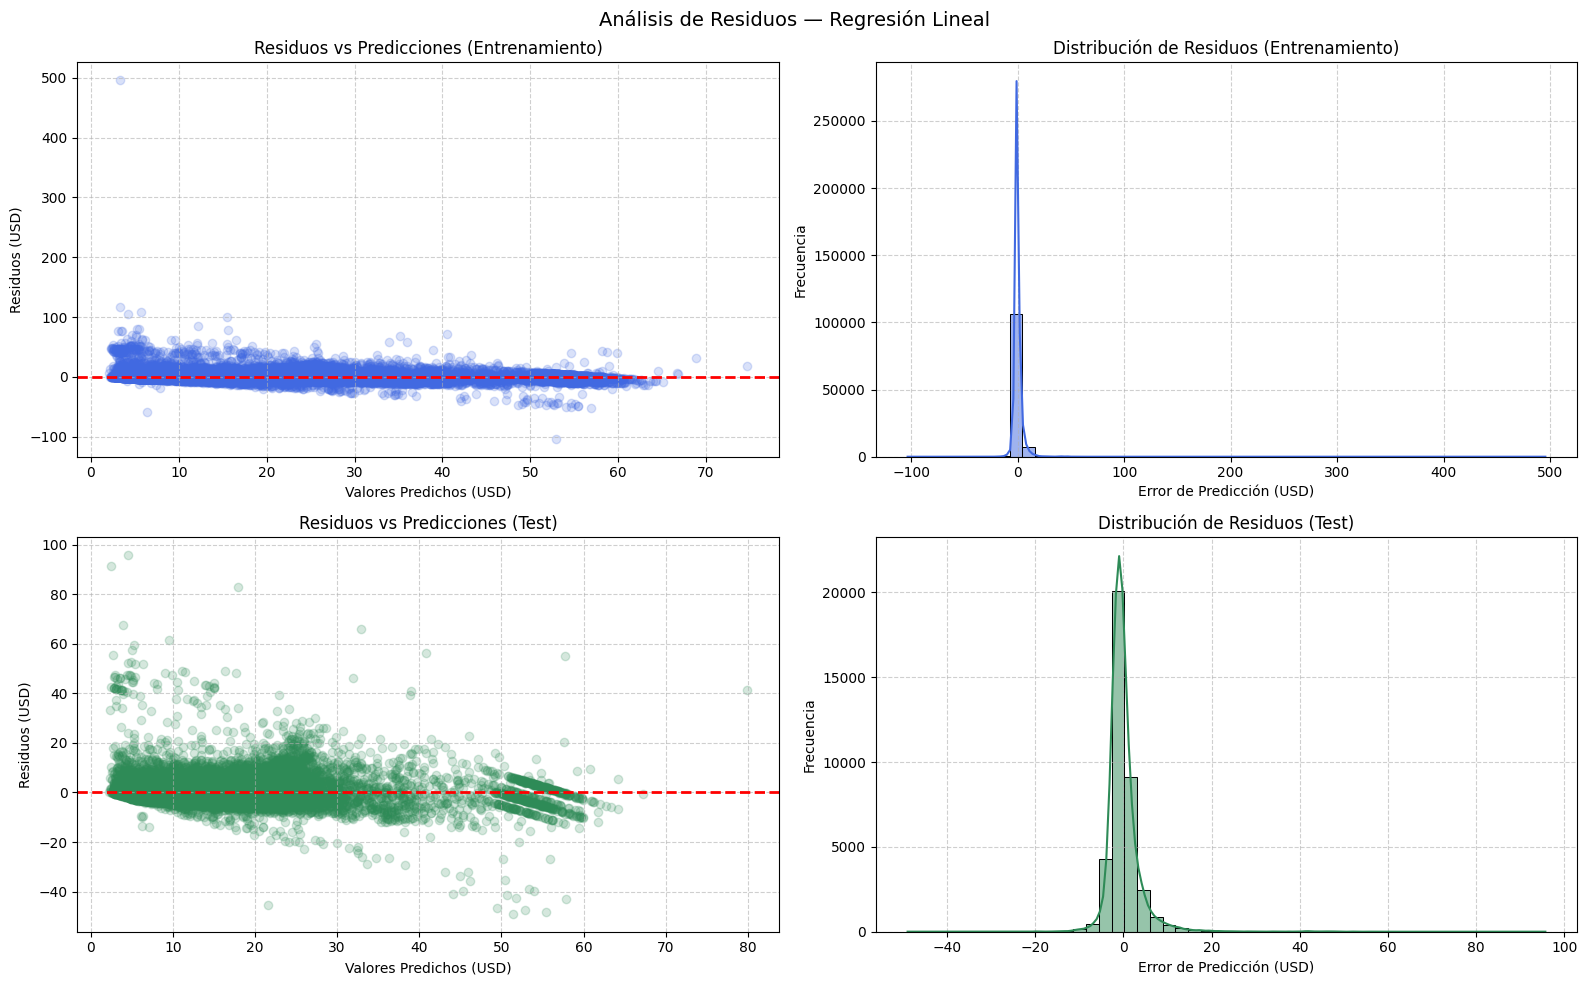

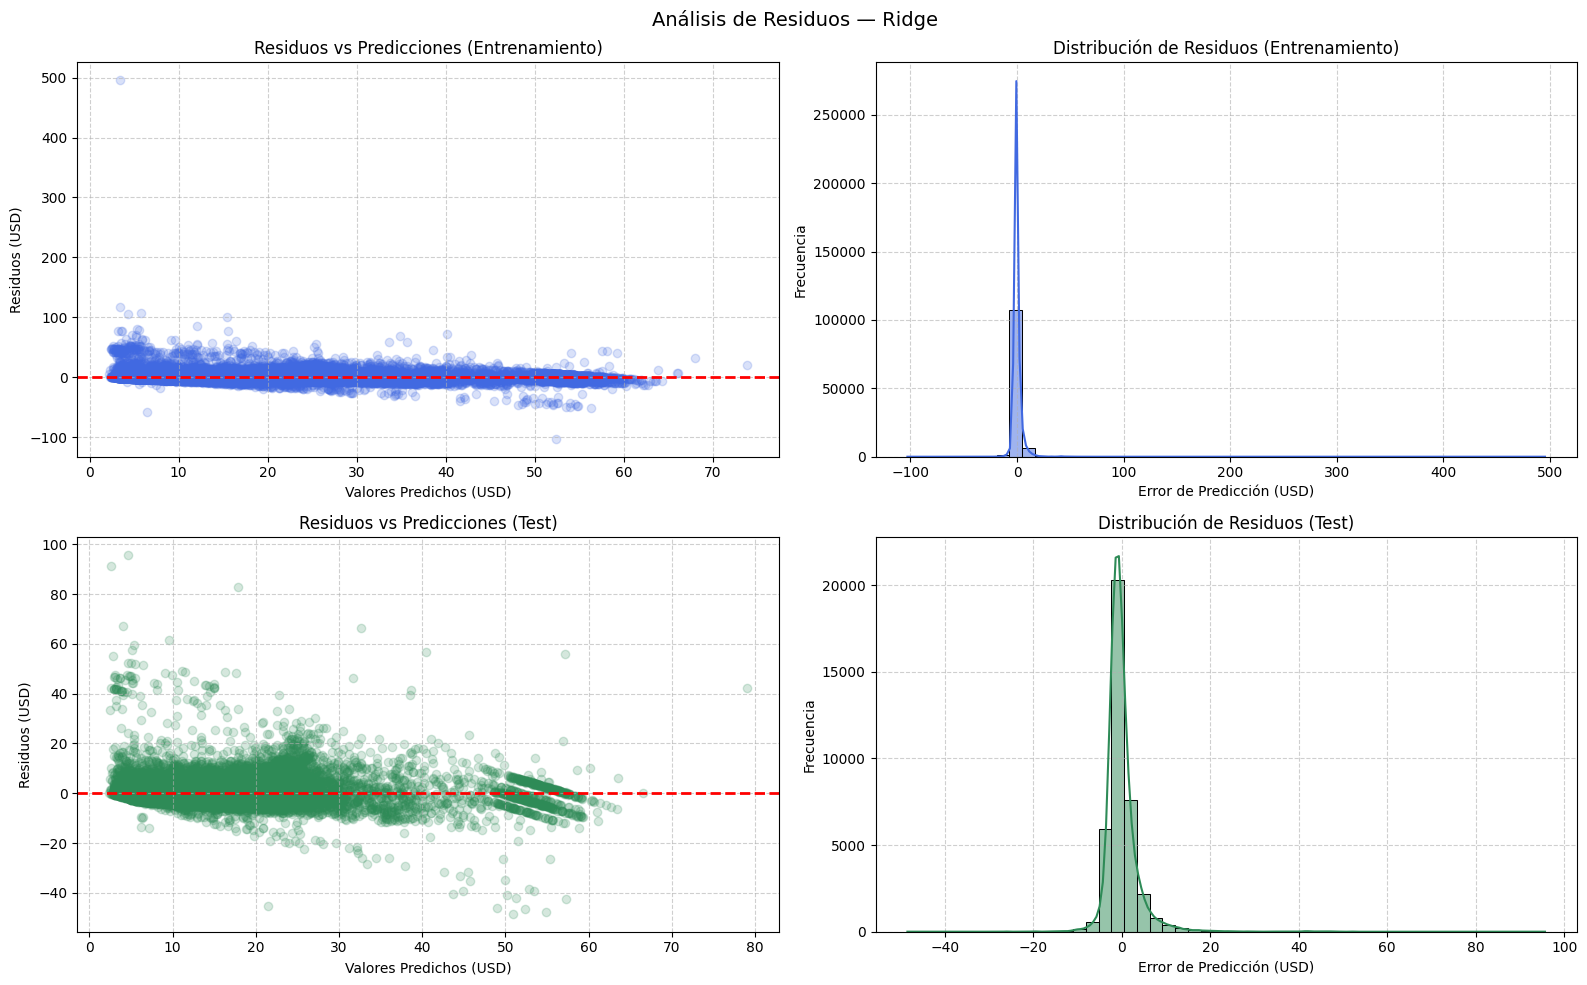

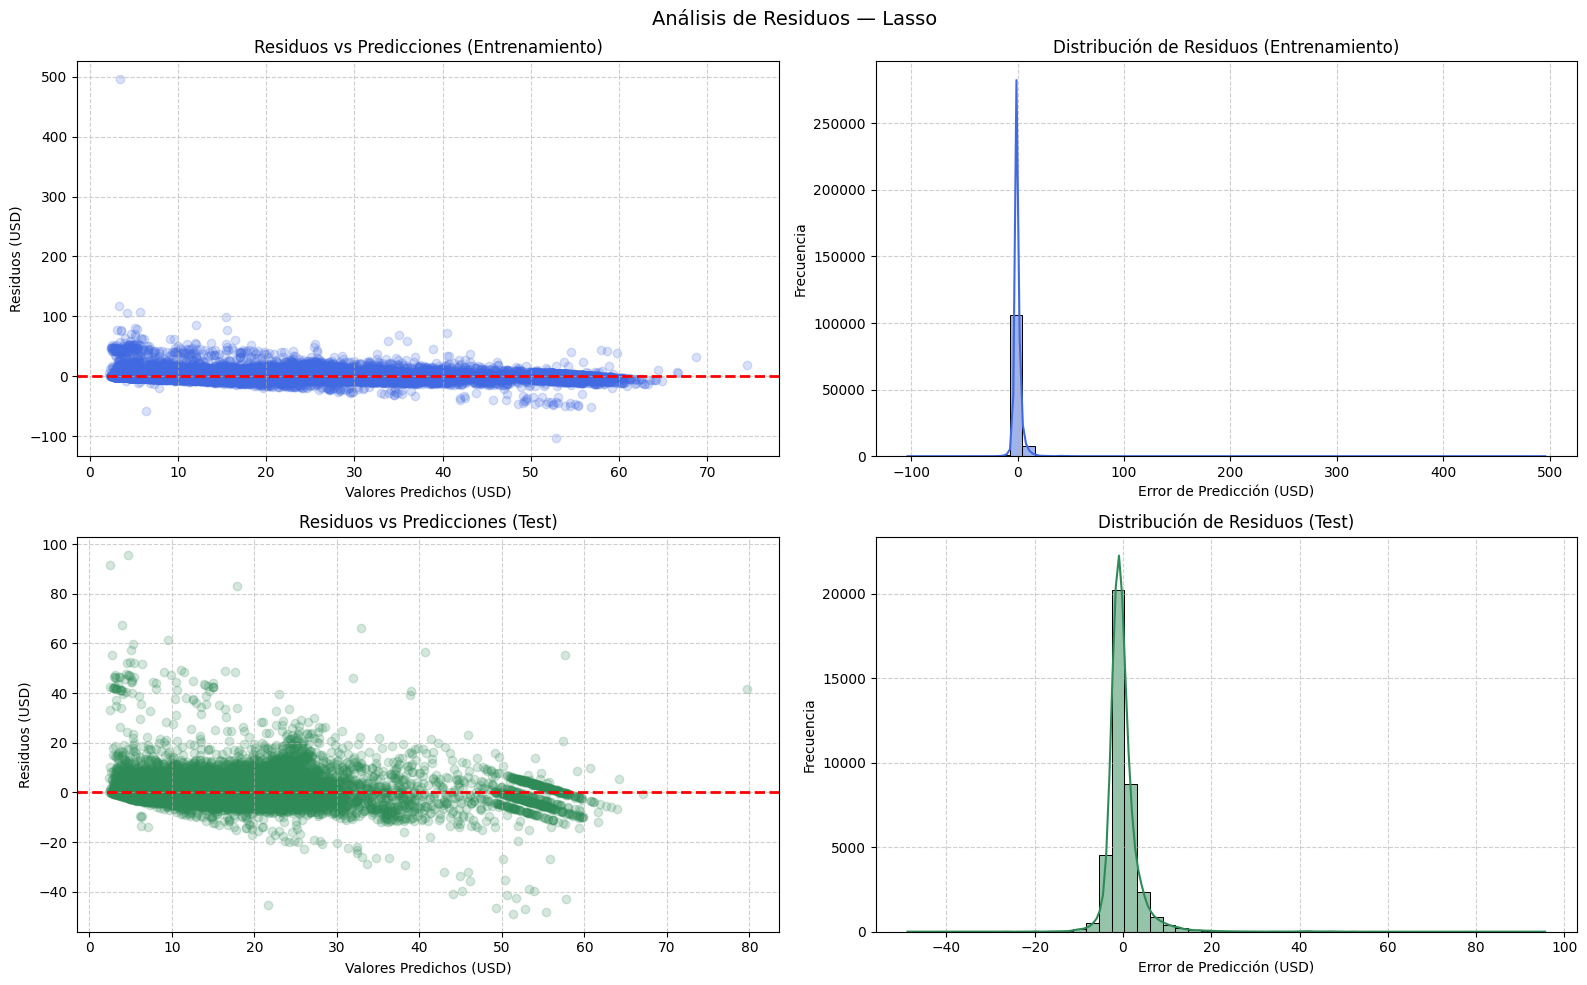

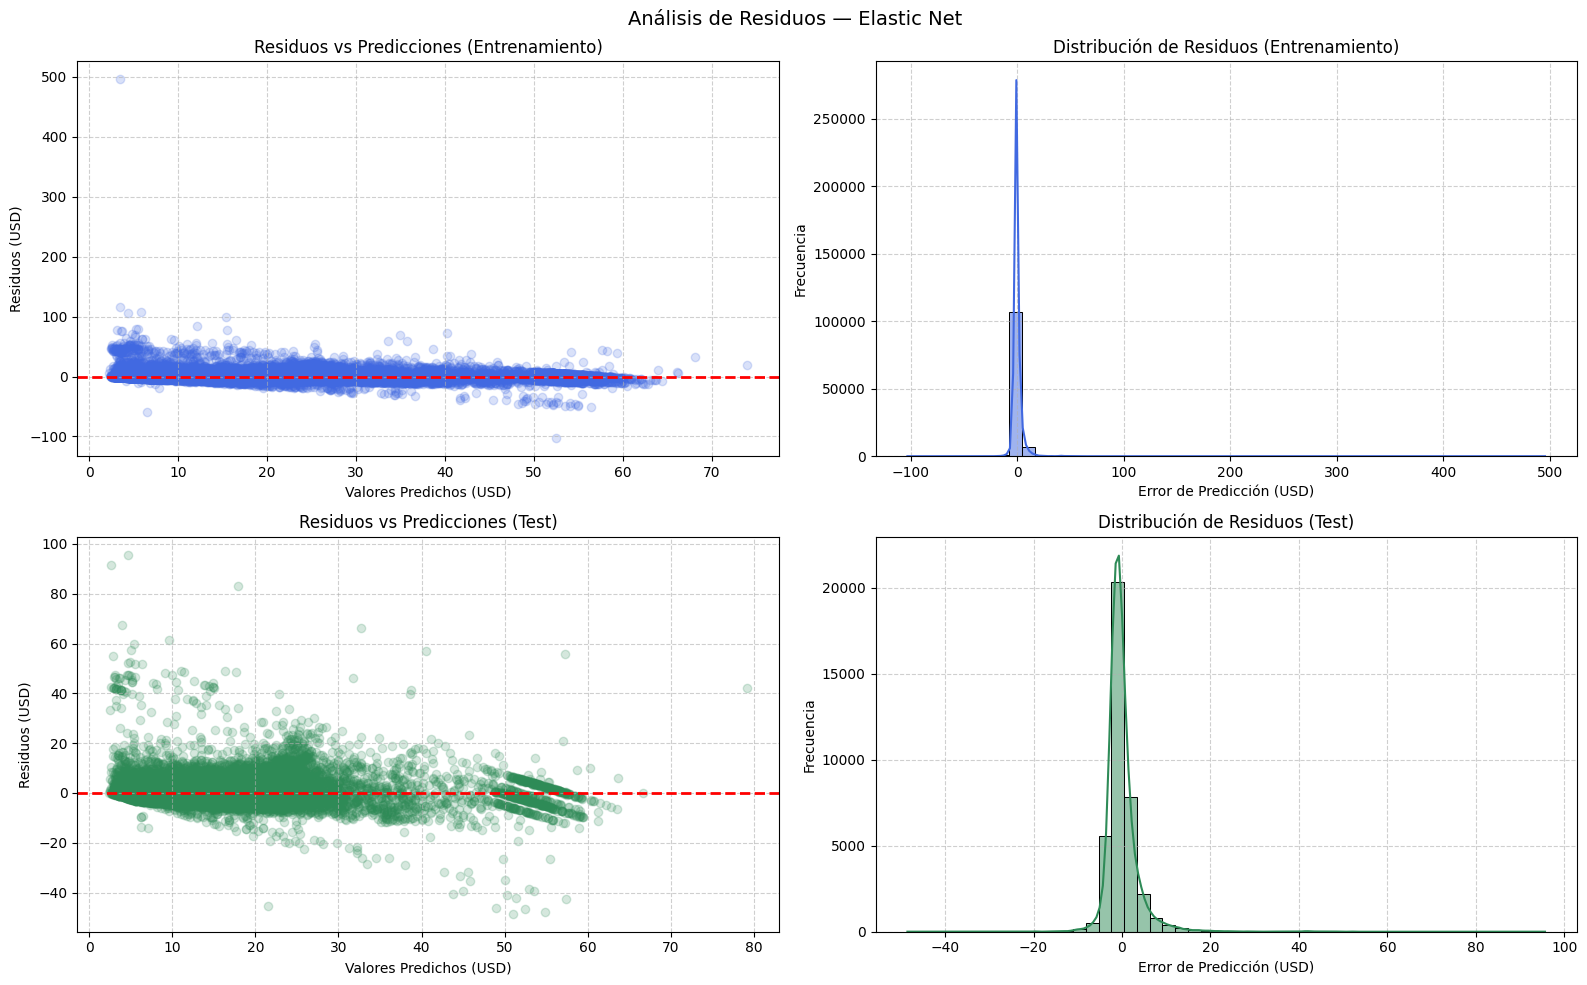

In [173]:
def graficar_residuos(modelo, X_train, y_train, X_test, y_test, nombre):
    pred_train  = modelo.predict(X_train)
    pred_test   = modelo.predict(X_test)
    resid_train = np.array(y_train) - pred_train
    resid_test  = np.array(y_test)  - pred_test

    fig, ax = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Análisis de Residuos — {nombre}', fontsize=14)

    # Entrenamiento
    ax[0,0].scatter(pred_train, resid_train, alpha=0.2, color='royalblue')
    ax[0,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax[0,0].set_title('Residuos vs Predicciones (Entrenamiento)')
    ax[0,0].set_xlabel('Valores Predichos (USD)')
    ax[0,0].set_ylabel('Residuos (USD)')
    ax[0,0].grid(True, linestyle='--', alpha=0.6)

    sns.histplot(resid_train, bins=50, kde=True, color='royalblue', ax=ax[0,1])
    ax[0,1].set_title('Distribución de Residuos (Entrenamiento)')
    ax[0,1].set_xlabel('Error de Predicción (USD)')
    ax[0,1].set_ylabel('Frecuencia')
    ax[0,1].grid(True, linestyle='--', alpha=0.6)

    # Test
    ax[1,0].scatter(pred_test, resid_test, alpha=0.2, color='seagreen')
    ax[1,0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax[1,0].set_title('Residuos vs Predicciones (Test)')
    ax[1,0].set_xlabel('Valores Predichos (USD)')
    ax[1,0].set_ylabel('Residuos (USD)')
    ax[1,0].grid(True, linestyle='--', alpha=0.6)

    sns.histplot(resid_test, bins=50, kde=True, color='seagreen', ax=ax[1,1])
    ax[1,1].set_title('Distribución de Residuos (Test)')
    ax[1,1].set_xlabel('Error de Predicción (USD)')
    ax[1,1].set_ylabel('Frecuencia')
    ax[1,1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Llamadas para cada modelo
graficar_residuos(model,               X_train_sc, y_train, X_test_sc, y_test, 'Regresión Lineal')
graficar_residuos(modelo_final_ridge,  X_train_sc, y_train, X_test_sc, y_test, 'Ridge')
graficar_residuos(modelo_final_lasso,  X_train_sc, y_train, X_test_sc, y_test, 'Lasso')
graficar_residuos(modelo_final_el,     X_train_sc, y_train, X_test_sc, y_test, 'Elastic Net')

# **Análisis y conclusión de los Gráficos de residuos**

Los cuatro modelos presentan residuos similares, lo que confirma que la regularización no introduce mejoras ni degradaciones significativas. En todos los casos se observa heterocedasticidad (mayor dispersión en viajes baratos), distribuciones centradas en cero y la misma cola derecha generada por outliers en el conjunto de entrenamiento.

**Ridge**

Los residuos se concentran cerca de cero tanto en entrenamiento como en test, con distribuciones simétricas y pico centrado. Se observa el mismo patrón que en la regresión lineal y el outlier de +500 USD en entrenamiento. El comportamiento es prácticamente idéntico al modelo lineal base, confirmando que la penalización L2 no alteró significativamente las predicciones.

**Elastic Net**

Gráficos virtualmente idénticos a Ridge y Regresión Lineal. La combinación L1+L2 con alpha óptimo de 0.0193 resultó tan baja que la penalización fue casi inexistente, produciendo coeficientes y residuos indistinguibles de los demás modelos.

**Lasso**

En el gráfico de test se observa una dispersión levemente mayor en los residuos negativos respecto a Ridge. Esto es consistente con el hecho de que Lasso eliminó o redujo algún coeficiente.



# **Optimización de hiperparámetros**



## Gradiente descendiente

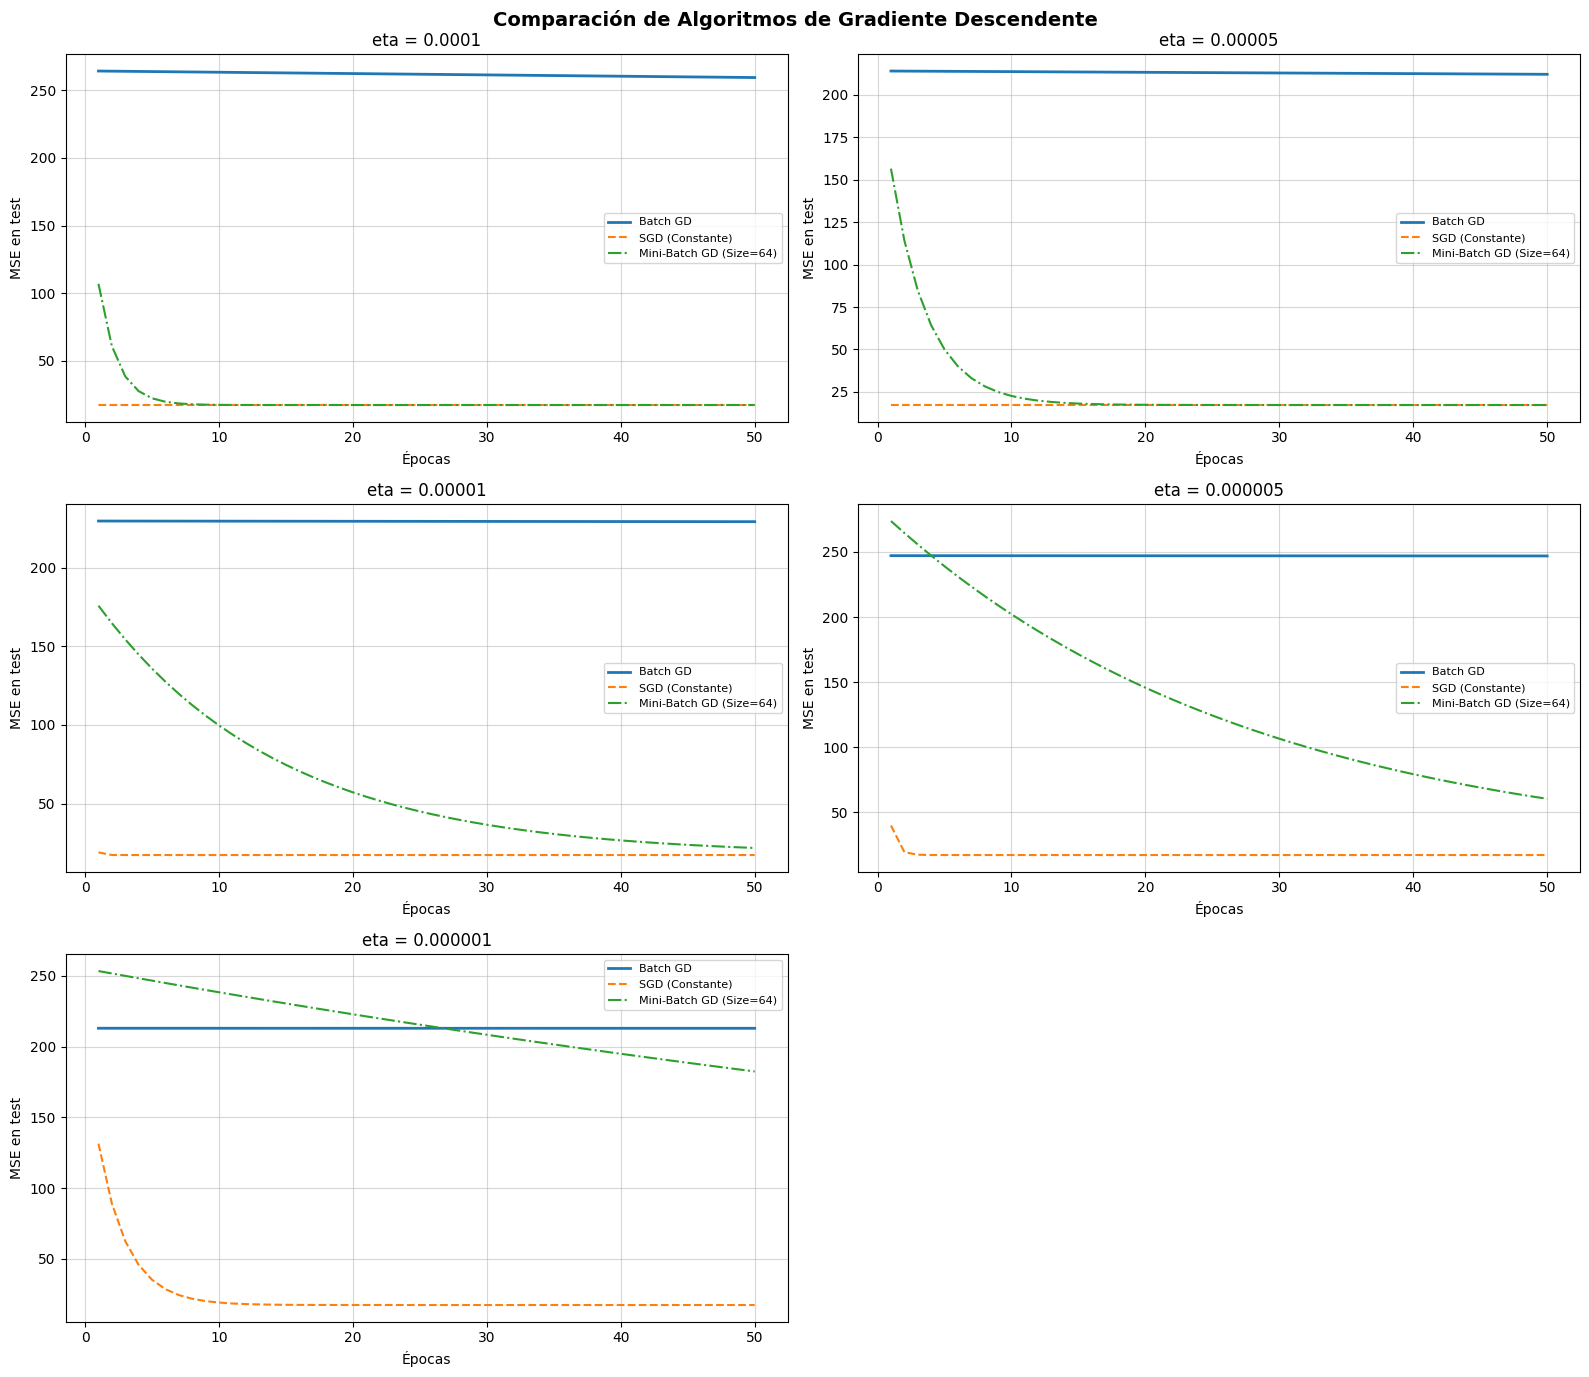

In [174]:
X_train_np = np.asarray(X_train_sc); X_test_np = np.asarray(X_test_sc)
y_train_np = np.asarray(y_train).reshape(-1, 1); y_test_np = np.asarray(y_test).reshape(-1, 1)
X_train_bias = np.c_[np.ones((len(X_train_np), 1)), X_train_np]
X_test_bias = np.c_[np.ones((len(X_test_np), 1)), X_test_np]

m = len(X_train_np)
n_features = X_train_np.shape[1]

n_epochs = 50
batch_size = 64
etas = [0.0001, 0.00005, 0.00001, 0.000005, 0.000001]

# Matriz de gráficos: 3 filas x 2 columnas (última celda vacía)
n_cols = 2
n_rows = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 14))
axes = axes.flatten()

all_errors = []

for idx, eta in enumerate(etas):

    theta_batch = np.random.randn(n_features + 1, 1)
    theta_sgd   = np.random.randn(n_features + 1, 1)
    theta_mbgd  = np.random.randn(n_features + 1, 1)

    errors = {"batch": [], "sgd": [], "minibatch": []}

    for epoch in range(n_epochs):
        permutation = np.random.permutation(m)
        X_shuffled  = X_train_bias[permutation]
        y_shuffled  = y_train_np[permutation]

        # BGD
        grad_batch   = 2 / m * X_train_bias.T.dot(X_train_bias.dot(theta_batch) - y_train_np)
        theta_batch -= eta * grad_batch

        # Mini-Batch
        for i in range(0, m, batch_size):
            xi_mbgd   = X_shuffled[i:i + batch_size]
            yi_mbgd   = y_shuffled[i:i + batch_size]
            grad_mbgd = 2 / len(xi_mbgd) * xi_mbgd.T.dot(xi_mbgd.dot(theta_mbgd) - yi_mbgd)
            theta_mbgd -= eta * grad_mbgd

        # SGD
        for i in range(m):
            xi_sgd   = X_shuffled[i:i + 1]
            yi_sgd   = y_shuffled[i:i + 1]
            grad_sgd = 2 * xi_sgd.T.dot(xi_sgd.dot(theta_sgd) - yi_sgd)
            theta_sgd -= eta * grad_sgd

        y_pred_batch = X_test_bias.dot(theta_batch)
        y_pred_sgd   = X_test_bias.dot(theta_sgd)
        y_pred_mbgd  = X_test_bias.dot(theta_mbgd)

        errors["batch"].append(mean_squared_error(y_test_np, y_pred_batch))
        errors["sgd"].append(mean_squared_error(y_test_np, y_pred_sgd))
        errors["minibatch"].append(mean_squared_error(y_test_np, y_pred_mbgd))

    ax = axes[idx]
    ax.plot(range(1, n_epochs + 1), errors["batch"],     label="Batch GD",                         linewidth=2)
    ax.plot(range(1, n_epochs + 1), errors["sgd"],       label="SGD (Constante)",                   linestyle='--')
    ax.plot(range(1, n_epochs + 1), errors["minibatch"], label=f"Mini-Batch GD (Size={batch_size})", linestyle='-.')
    ax.set_xlabel("Épocas")
    ax.set_ylabel("MSE en test")
    ax.set_title(f"eta = {eta:.7f}".rstrip('0'))
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.5)

# Ocultar la última celda vacía (5 etas, 6 celdas)
axes[-1].set_visible(False)

fig.suptitle("Comparación de Algoritmos de Gradiente Descendente", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El BGD requiere learning rates más altos para converger ya que actualiza los pesos una sola vez por época.

El SGD es el más robusto ante learning rates bajos por la frecuencia de sus actualizaciones.

El Mini-Batch necesita un balance adecuado (con eta = 0.0001) logra el mejor resultado, pero con etas muy bajos no alcanza a converger en 50 épocas.

## Lasso y Ridge

In [175]:
# Alphas distintas para probar
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

#  Ridge
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train_sc, y_train)

    y_train_pred = model.predict(X_train_sc)
    y_test_pred = model.predict(X_test_sc)

    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })


# Lasso
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_sc, y_train)

    y_train_pred = model.predict(X_train_sc)
    y_test_pred = model.predict(X_test_sc)

    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })

df_results_opt = pd.DataFrame(results)
df_results_opt

,Modelo,Alpha,Conjunto,R2,MSE
0,Ridge,0.001,train,0.771418,19.164019
1,Ridge,0.001,test,0.787637,17.296715
2,Ridge,0.010,train,0.771418,19.164019
3,Ridge,0.010,test,0.787637,17.296715
4,Ridge,0.100,train,0.771418,19.164019
5,Ridge,0.100,test,0.787637,17.296715
6,Ridge,1.000,train,0.771418,19.164019
7,Ridge,1.000,test,0.787637,17.296712
8,Ridge,10.000,train,0.771418,19.164020
9,Ridge,10.000,test,0.787637,17.296687


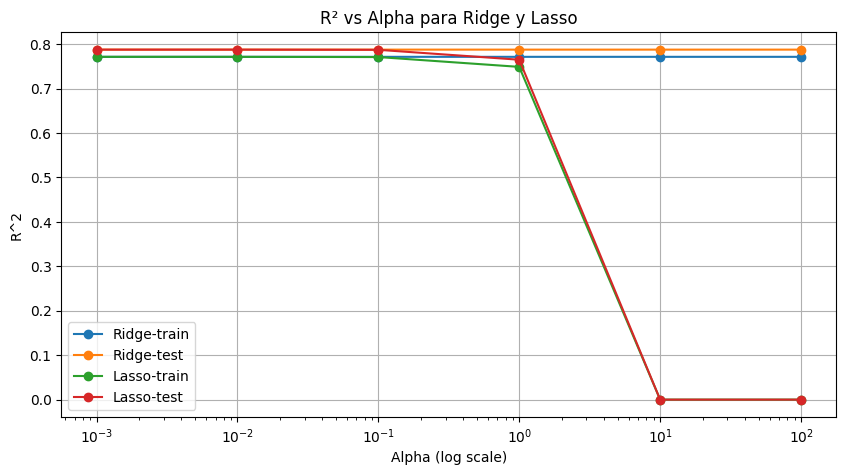

In [176]:
plt.figure(figsize=(10,5))
for model_name in ['Ridge','Lasso']:
    for conjunto in ['train','test']:
        subset = df_results_opt[(df_results_opt['Modelo']==model_name) & (df_results_opt['Conjunto']==conjunto)]
        plt.plot(subset['Alpha'], subset['R2'], marker='o', label=f"{model_name}-{conjunto}")

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("R^2")
plt.title("R² vs Alpha para Ridge y Lasso")
plt.legend()
plt.grid(True)
plt.show()

**Ridge**: R^2 se mantiene estable en 0.78 aproximadamente en todo el rango de Alphas

**Lasso**: Funciona correctamente hasta alpha 0.1 aproximadamente y a partir de alpha = 1 el R^2 colapsa a 0.

Ridge es mas robusto ya que funciona bastante bien para todos los valores de Alpha manteniendolo estable, mientras que Lasso requiere una calibración más precisa del alpha para no destruir el modelo, ya que elimina variables (en este caso significantes para el modelo).

# Comparación de modelos

In [177]:
modelos_a_comparar = [
    ("LinearRegression", LinearRegression(),                    "-"),
    ("Ridge",            Ridge(alpha=mejor_alpha_ridge),        f"{mejor_alpha_ridge:.4f}"),
    ("Lasso",            Lasso(alpha=mejor_alpha_lasso),        f"{mejor_alpha_lasso:.4f}"),
    ("ElasticNet",       ElasticNet(alpha=mejor_alpha_elastic), f"{mejor_alpha_elastic:.4f}")
]

resultados_tabla = []

for nombre, modelo, alpha_val in modelos_a_comparar:
    modelo.fit(X_train_sc, y_train)

    pred_train = modelo.predict(X_train_sc)
    pred_test = modelo.predict(X_test_sc)

    r2_train = r2_score(y_train, pred_train)
    r2_test = r2_score(y_test, pred_test)
    mse_train = mean_squared_error(y_train, pred_train)
    mse_test = mean_squared_error(y_test, pred_test)

    resultados_tabla.append({
        'Modelo': nombre,
        'Alpha': alpha_val,
        'R2_train': r2_train,
        'R2_test': r2_test,
        'MSE_train': mse_train,
        'MSE_test': mse_test
    })

comparacion = pd.DataFrame(resultados_tabla)

comparacion = comparacion.round(6)

comparacion

#Alpha es el hiperparámetro que controla la "fuerza" de la penalización en modelos como Ridge, Lasso y ElasticNet.

#Como la LinearRegression estándar no tiene penalización (no intenta achicar los coeficientes,
#(solo busca el error mínimo), el valor de Alpha simplemente no existe para ese algoritmo.



,Modelo,Alpha,R2_train,R2_test,MSE_train,MSE_test
0,LinearRegression,-,0.771418,0.787637,19.164019,17.296715
1,Ridge,1526.4180,0.771288,0.787555,19.174950,17.303331
2,Lasso,0.0193,0.771395,0.787629,19.165926,17.297302
3,ElasticNet,0.0193,0.771322,0.787585,19.172069,17.300938


## **Conclusión de comparación de Modelos**

**Métrica elegida:**

Para realizar esta comparación se eligió el Error Cuadrático Medio (MSE) como métrica principal porque permite interpretar el error en las mismas unidades del problema (USD) y penaliza con mayor peso los errores grandes, lo cual es relevante en la predicción de tarifas.
Se complementó con R² para evaluar la capacidad explicativa del modelo

La Regresión Lineal es preferible ya que es el modelo más simple y más fácil de explicar. Aunque si se prefiere un modelo regularizado (a pesar de no obtener casi ninguna diferencia) Ridge sería una buena opción.

# **Conclusión final**

El objetivo del trabajo fue predecir el precio de viajes de Uber en Nueva York mediante regresión lineal múltiple. Luego del preprocesamiento, que incluyó eliminación de datos faltantes, filtrado de coordenadas inválidas y restricción geográfica a Nueva York, se trabajó con un dataset representativo y limpio.

El análisis exploratorio reveló que la variable con mayor poder predictivo es la distancia recorrida, con una correlación lineal fuerte y positiva respecto al precio. Las variables temporales (hora, día, mes, año) aportaron información complementaria pero de menor peso.

Todos los modelos evaluados alcanzaron un rendimiento similar, con un R2 de aproximadamente 0.79 y un MAE de 2.32 dólares aproximadante, lo que indica que el modelo se equivoca en promedio 2.32 USD por viaje. La consistencia entre las métricas de entrenamiento y prueba en todos los casos confirma ausencia de overfitting.

Respecto a la regularización, Ridge demostró ser el método más robusto al mantener un MSE estable en todo el rango de alphas. Lasso y Elastic Net requirieron alphas muy bajos para no degradar el modelo, ya que con penalizaciones mayores eliminan variables relevantes.

Las diferencias entre los cuatro modelos en la comparación final fueron despreciables (MSE entre 17.29 y 17.30), lo que indica que el límite predictivo está impuesto por las features disponibles y no por el algoritmo.

En cuanto al gradiente descendente, Mini-Batch GD fue el método más eficiente, logrando convergencia rápida y estable. BGD resultó demasiado lento con los learning rates probados, y SGD mostró inestabilidad en validación pese a converger en entrenamiento.


Como conclusión final, se llegó a que el modelo más adecuado es el de Regresión lineal por su simpleza e interpretación sin necesidad de incluir hiperparámetros adicionales.